**DATA LOADING AND CLEANING**

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("online_retail_II.csv")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(34335)

In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [8]:
df.shape

(1067371, 8)

In [9]:
df = df.dropna(subset=['Customer ID']) #remove missing values where customer ID is not present 

In [10]:
df.shape

(824364, 8)

In [11]:
df = df.drop_duplicates()  #remove duplicates

In [12]:
df.shape

(797885, 8)

In [13]:
#convert date column 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  #changed invoicedate datatype from object to datetime

In [14]:
df.info()   #InvoiceDate  797885 non-null  datetime64[ns]

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  float64       
 7   Country      797885 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 54.8+ MB


In [15]:
# Check negative quantity means returned or cancelled orders
(df["Quantity"]<0).sum()  
#For customer segmentation we genrally remove negative quantity 

np.int64(18390)

In [16]:
df.shape

(797885, 8)

In [17]:
df['Price'].isnull().sum()

np.int64(0)

In [18]:
(df['Price'].astype(str).str.strip()==" ").sum()

np.int64(0)

In [19]:
(df['Price']==00).sum()

np.int64(70)

In [20]:
(df["Price"]<0).sum()

np.int64(0)

In [21]:
#remove negative quantity 
df = df[df['Quantity']>0]

In [22]:
#remove zero price
df = df[df['Price']>0]

In [23]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [24]:
df['TotalAmount'] = df['Quantity']*df['Price']

In [25]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [26]:
df[['Quantity' , 'Price' , 'TotalAmount']].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [27]:
df['Customer ID']=df['Customer ID'].astype(int)

In [28]:
df.shape

(779425, 9)

**SAVING CLEANED DATASET**

In [29]:
# df.to_csv("cleaned_online_retail_2.csv" , index = False)

**EDA(EXPOLATORY DATA ANALYSIS)**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  object        
 8   TotalAmount  779425 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 59.5+ MB


In [31]:
df['Quantity'].describe()


count    779425.000000
mean         13.489370
std         145.855814
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [43]:
df['TotalAmount'].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

In [44]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalAmount
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


In [58]:
df['Country'].value_counts().head(10)  #top countries 

Country
United Kingdom    700388
Germany            16432
EIRE               15565
France             13511
Netherlands         5085
Spain               3662
Belgium             3055
Switzerland         3005
Portugal            2356
Australia           1789
Name: count, dtype: int64

<Axes: xlabel='Country'>

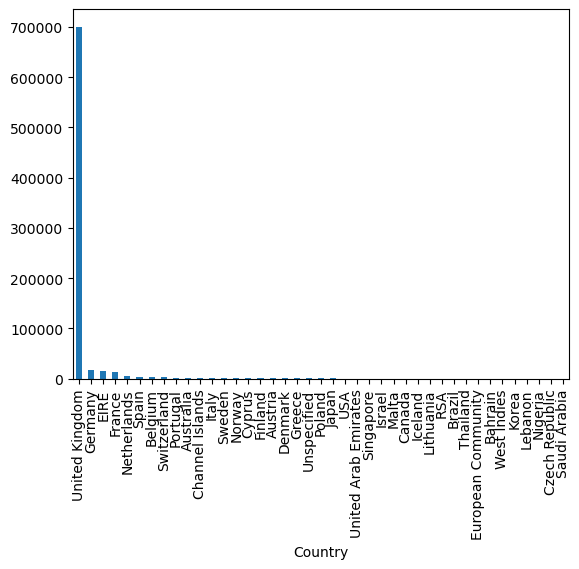

In [48]:
df['Country'].value_counts().plot(kind='bar')

In [52]:
df.groupby("Description")['TotalAmount'].sum().sort_values(ascending = False).head(10) #Finding top revenue prodducts

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalAmount, dtype: float64

<Axes: xlabel='Description'>

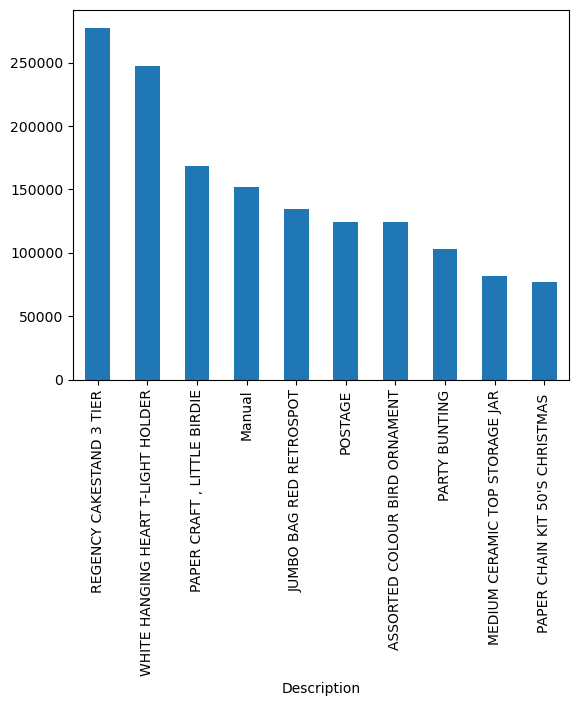

In [56]:
df.groupby("Description")['TotalAmount'].sum().sort_values(ascending = False).head(10).plot(kind='bar')

In [53]:
#Finding our top customers 
df.groupby("Customer ID")["TotalAmount"].sum().sort_values(ascending=False).head(10)

Customer ID
18102    580987.04
14646    528602.52
14156    313437.62
14911    291420.81
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144458.37
Name: TotalAmount, dtype: float64

<Axes: xlabel='Customer ID'>

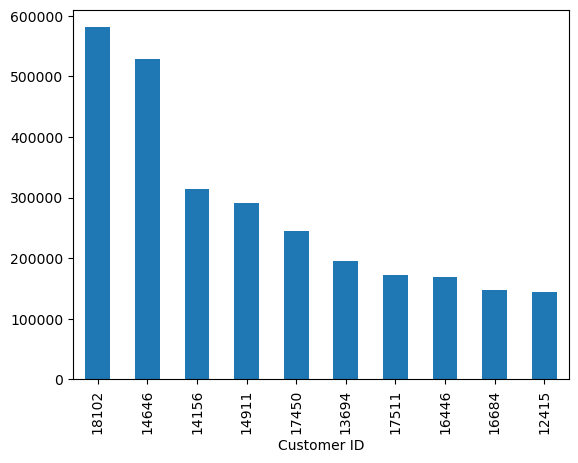

In [54]:
df.groupby("Customer ID")["TotalAmount"].sum().sort_values(ascending=False).head(10).plot(kind = 'bar')

In [63]:
# Time based analysis:-

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [72]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,Tuesday,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12,Friday,12
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,Friday,12
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,Friday,12
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,12,Friday,12


Month
1     1123903.982
2      950643.876
3     1291060.231
4     1060356.333
5     1275188.530
6     1296417.180
7     1188699.071
8     1246275.640
9     1779704.153
10    2068754.460
11    2322665.632
12    1771135.180
Name: TotalAmount, dtype: float64


<Axes: xlabel='Month'>

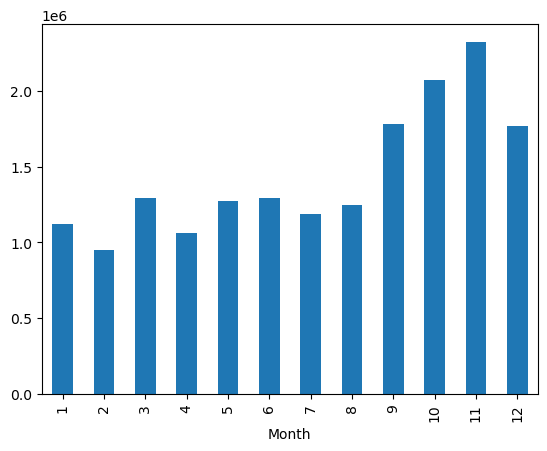

In [69]:
print(df.groupby("Month")['TotalAmount'].sum())
df.groupby("Month")['TotalAmount'].sum().plot(kind='bar')

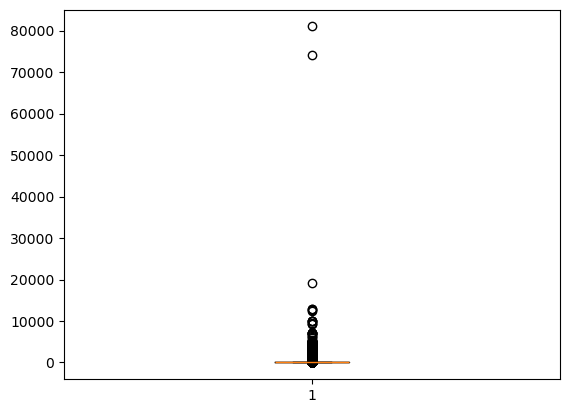

In [81]:
plt.boxplot(x=df['Quantity'])
plt.show()

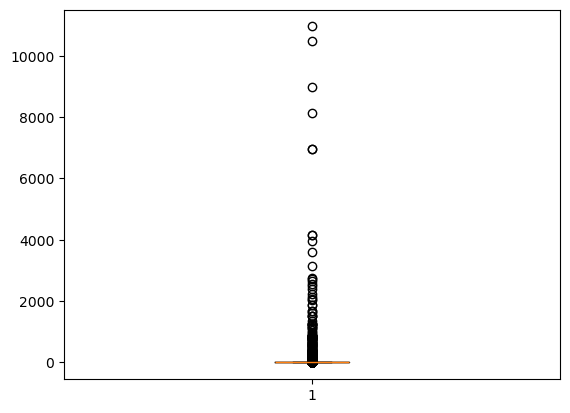

In [77]:
plt.boxplot(x=df['Price'])
plt.show()

In [100]:
#customer segmentation 
#RFM Features
#Finding latest date 
reference_date = df['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [101]:
# calculating difference of customer from latest purchase

# RFM table:-

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ['Recency' , 'Frequency' , 'Monetary']

In [102]:
print(rfm.shape) 
rfm.describe()

(5878, 3)


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,342.280000
50%,95.000000,3.000000,867.740000
75%,379.000000,7.000000,2248.305000
max,738.000000,398.000000,580987.040000


In [103]:
#using IQR methode to remove outliers 
def remove_outliers(df,column): 
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    return df[(df[column]>=lower)&(df[column]<=upper)]

rfm_clean = remove_outliers(rfm,'Monetary')
rfm_clean = remove_outliers(rfm_clean,'Frequency')
rfm_clean = remove_outliers(rfm_clean,'Recency')

print(rfm.shape)
print(rfm_clean.shape)

(5878, 3)
(4989, 3)


In [116]:
# now applying StandardScaling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean[['Recency','Frequency','Monetary']])

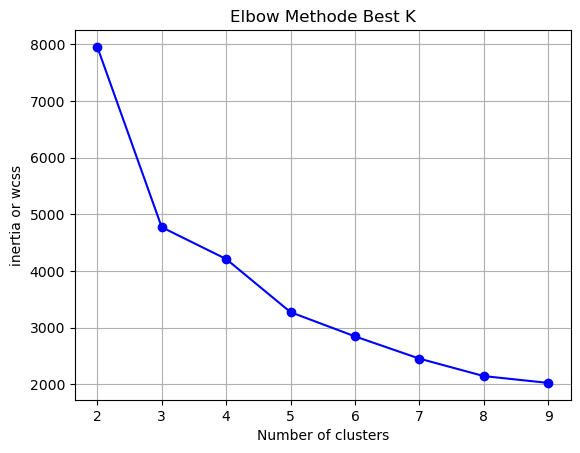

In [117]:
#applying Elbow methode 
import warnings
warnings.filterwarnings("ignore")
inertia = []
for k in range(2,10):
    km = KMeans(n_clusters=k , random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10),inertia,marker='o',color ='blue')
plt.title("Elbow Methode Best K")
plt.xlabel('Number of clusters')
plt.ylabel("inertia or wcss")
plt.grid(True)
plt.show()

In [118]:
#from the elbow diagram we can clearly see that after 6 cluster the values are not falling sudden so we choose number of cluster = 6

In [119]:
print(rfm_clean.columns)

Index(['Recency', 'Frequency', 'Monetary', 'Cluster'], dtype='object')


In [128]:
print(rfm_clean.groupby("Cluster")[['Recency', 'Frequency', 'Monetary']].mean().round(2))

         Recency  Frequency  Monetary
Cluster                              
0         175.83       3.68   1005.49
1          93.61       6.98   2874.16
2          90.50       7.83   4179.83
3         105.07       1.98    368.64
4         499.48       1.40    275.73
5         137.19       5.54   1822.28


In [129]:
#Assigning cell names 
cluster_names = {
    0:'Potential loyalists', 
    1:"Loyal customers", 
    2:"Champions", 
    3:"New customer", 
    4:"Lost customer", 
    5:"At risk"
}
rfm_clean['Segment']=rfm_clean['Cluster'].map(cluster_names)

In [130]:
rfm_clean['Segment'].value_counts()

Segment
Lost customer          1291
New customer           1269
Potential loyalists    1191
At risk                 668
Loyal customers         365
Champions               205
Name: count, dtype: int64

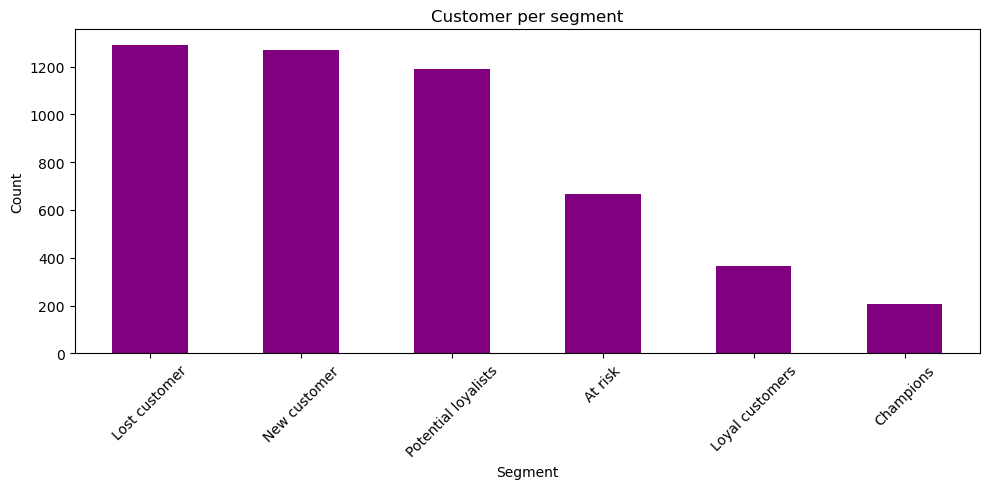

In [131]:
plt.figure(figsize=(10,5))
rfm_clean['Segment'].value_counts().plot(kind ='bar',color='purple')
plt.title("Customer per segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

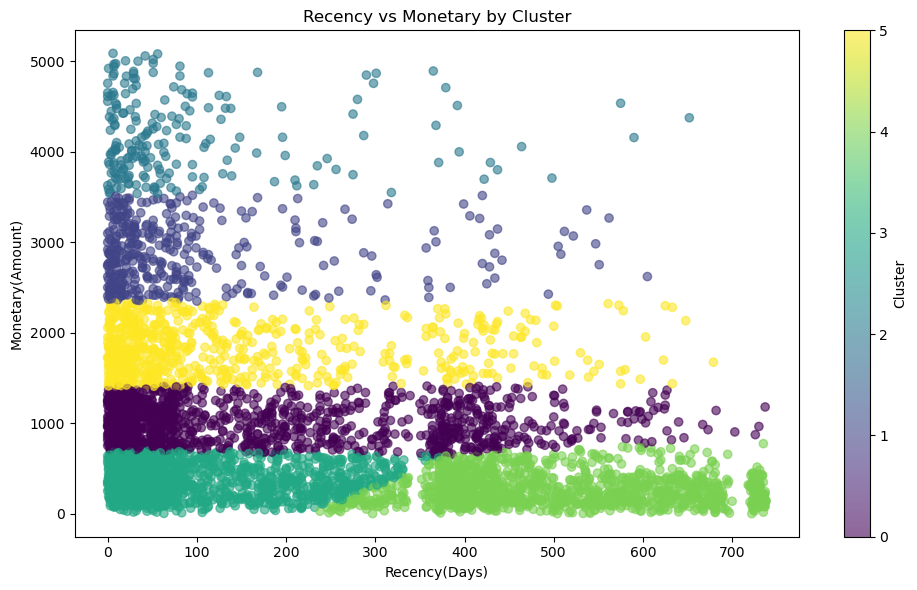

In [134]:
plt.figure(figsize =(10,6))
scatter = plt.scatter(rfm_clean['Recency'],rfm_clean['Monetary'],c=rfm_clean['Cluster'],cmap='viridis',alpha=0.6)
plt.colorbar(scatter,label='Cluster')
plt.title("Recency vs Monetary by Cluster")
plt.xlabel("Recency(Days)")
plt.ylabel("Monetary(Amount)")
plt.tight_layout()
plt.show()

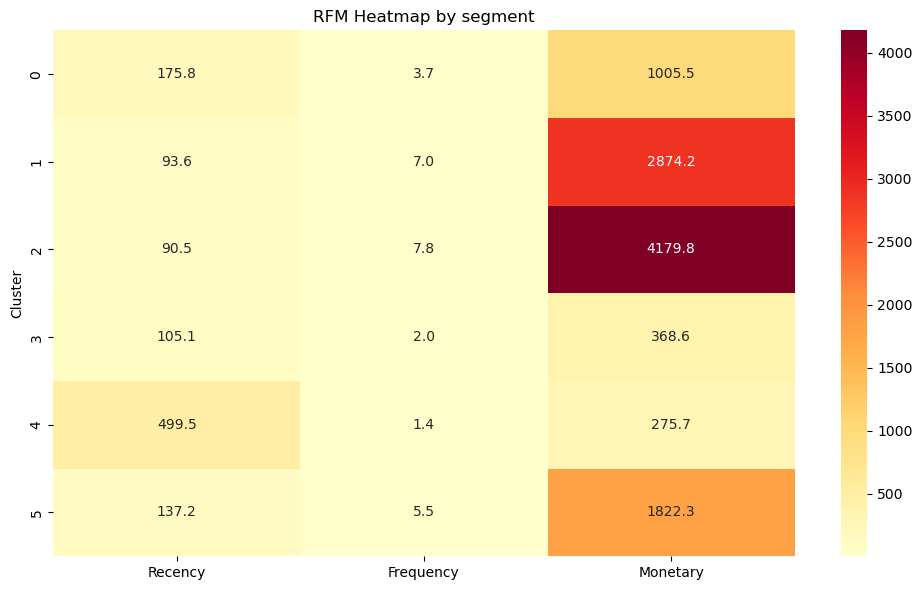

In [136]:
segment_Summary =rfm_clean.groupby("Cluster")[['Recency', 'Frequency', 'Monetary']].mean().round(2)

plt.figure(figsize = (10,6))
sns.heatmap(segment_Summary , annot= True , fmt='.1f' , cmap='YlOrRd')
plt.title("RFM Heatmap by segment")
plt.tight_layout()
plt.show()

In [166]:
rfm_clean = rfm_clean[['Customer ID','Recency','Frequency','Monetary','Cluster','Segment']]
rfm_clean.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster',
       'Segment'],
      dtype='object')

In [167]:
#let see customers list in every clustures 
# checking customers in each segment 

for segment in rfm_clean['Segment'].unique():
    customer = rfm_clean[rfm_clean['Segment']==segment]
    print(f'\n{segment}:{len(customer)}customer')
    print(customer[["Customer ID","Recency","Frequency","Monetary"]].head(3))


Champions:205customer
   Customer ID  Recency  Frequency  Monetary
0        12347        1          8   4921.53
2        12349       18          4   4428.69
9        12358        1          5   3887.07

At risk:668customer
    Customer ID  Recency  Frequency  Monetary
1         12348       74          5   2019.40
18        12369      412          3   1791.15
27        12379       81          4   1620.22

Lost customer:1291customer
    Customer ID  Recency  Frequency  Monetary
3         12350      309          1    334.40
4         12351      374          1    300.93
15        12366      633          1    500.24

Loyal customers:365customer
    Customer ID  Recency  Frequency  Monetary
5         12352       35         10   2849.84
23        12374       24          4   2989.22
26        12377      314          4   3426.32

New customer:1269customer
    Customer ID  Recency  Frequency  Monetary
6         12353      203          2    406.76
11        12361      286          4    511.25
12

In [168]:
rfm_clean.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster',
       'Segment'],
      dtype='object')

In [169]:
rfm_clean.index

RangeIndex(start=0, stop=4989, step=1)

In [164]:
#saving customers ids of each segment 
# for segment in rfm_clean['Segment'].unique():
#     seg_df = rfm_clean[rfm_clean["Segment"]==segment]
#     filename = f'{segment.replace("","_")}.csv'
#     # seg_df.to_csv(filename , index = False)

In [170]:
rfm_clean.to_csv('rfm_segments.csv', index = False)